Demographics analyzer

In [1]:
import numpy as np
import pandas as pd
import math
import ast

# format print
def p(des, count, total):
    print(des + ':  '+ str(count)+'  |  '+str(round(100.0*count/total, 1 ))+ '%')

def find(id, df):
    if not (df[df['ID']==id].empty):
        return df[df['ID']==id]
    print("\nERROR--ID NOT FOUND: "+ id + '\n')

# input: a list of ID and a complete dataset df
def analyze(l, df):
    s = len(l)

    # list of observation periods
    ob_l = []

    # list of avg visit intervals
    vi_l = []

    # list of ages 
    a_l = []
    # age groups counts
    age51 = 0 # 50-60
    age61 = 0
    age71 = 0
    age81 = 0 # 81-90
    age91 = 0 # 91&+

    # sex
    m = 0
    f = 0

    # RACE
    white = 0
    black = 0
    ai = 0
    nh = 0
    asian = 0
    other = 0

    # HISPANIC
    hispanic = 0
    not_hispanic = 0

    # comorbidities
    alcohol = 0
    heart_attack = 0
    atrial_fibrillation = 0
    diabetes = 0
    hypercholesteromia = 0
    hypertension = 0
    vb12 = 0
    depression = 0
    anxiety = 0
    trauma = 0

    # APOE
    e1 = 0
    e2 = 0

    for i in l:
        row = find(i, df)

        # fail-safe
        if (row is None):
            continue
        
        # visit interval
        if isinstance(row.iloc[0]['months_since_baseline'], str):
            msb = eval(row.iloc[0]['months_since_baseline'])
            ob_l.append(msb[-1])
            vi_l.append(msb[-1]/(int(row.iloc[0]['n_visits'])-1)) 

        # AGE
        age = int(row.iloc[0]['age'])
        a_l.append(age)
        if age<50:
            skip=''
        elif age<61:
            age51+=1
        elif age<71:
            age61+=1
        elif age<81:
            age71+=1
        elif age<91:
            age81+=1
        else: 
            age91+=1
        
        # sex
        sex = int(row.iloc[0]['SEX'])
        if sex==1:
            m+=1
        elif sex==2:
            f+=1

        # RACE
        if not (math.isnan(row.iloc[0]["RACE"])):
            race= int(row.iloc[0]['RACE'])
            if race==1:
                white+=1
            elif race==2:
                black+=1
            elif race==3:
                ai+=1
            elif race==4:
                nh+=1
            elif race==5:
                asian+=1
            else: other+=1
        else:
            print("\nwarning: "+i+" has a RACE value of "+str(row.iloc[0]["RACE"]))

        # HISPANIC
        if not (math.isnan(row.iloc[0]["HISPANIC"])):
            if (int(row.iloc[0]['HISPANIC'])==1):
                hispanic+=1
            else: not_hispanic+=1

        # comorbidities
        # if not (math.isnan(row.iloc[0]["ALCOHOL"])):
        #     if (int(row.iloc[0]['ALCOHOL'])==1):
        #         alcohol+=1
    
        if not (math.isnan(row.iloc[0]["CVHATT"])):
            if (int(row.iloc[0]['CVHATT'])==1):
                heart_attack+=1
    
        if not (math.isnan(row.iloc[0]["CVAFIB"])):
            if (int(row.iloc[0]['CVAFIB'])==1):
                atrial_fibrillation+=1
    
        if not (math.isnan(row.iloc[0]["DIABETES"])):
            if (int(row.iloc[0]['DIABETES'])==1):
                diabetes+=1
    
        if not (math.isnan(row.iloc[0]["HYPERCHO"])):
            if (int(row.iloc[0]['HYPERCHO'])==1):
                hypercholesteromia+=1
    
        if not (math.isnan(row.iloc[0]["HYPERTEN"])):
            if (int(row.iloc[0]['HYPERTEN'])==1):
                hypertension+=1
    
        if not (math.isnan(row.iloc[0]["B12DEF"])):
            if (int(row.iloc[0]['B12DEF'])==1):
                vb12+=1
    
        if not (math.isnan(row.iloc[0]["DEPD"])):
            if (int(row.iloc[0]['DEPD'])==1):
                depression+=1
    
        if not (math.isnan(row.iloc[0]["ANX"])):
            if (int(row.iloc[0]['ANX'])==1):
                anxiety+=1
    
        if not (math.isnan(row.iloc[0]["NACCTBI"])):
            if (int(row.iloc[0]['NACCTBI'])==1):
                trauma+=1

        # APOE
        if not (math.isnan(row.iloc[0]["NACCNE4S"])):
            if (int(row.iloc[0]['NACCNE4S'])==1):
                e1+=1
            
            if (int(row.iloc[0]['NACCNE4S'])==2):
                e2+=1

    # convert all lists to pd series for quick summary
    a_l = pd.Series(a_l)
    vi_l = pd.Series(vi_l)
    ob_l = pd.Series(ob_l)

    print(f"n = {s}")
    # avg observation period.
    print(f"averag observation period: {ob_l.mean()} ± {ob_l.std()} months")
    print(f"range: {ob_l.min()} - {ob_l.max()}")
    print(f"    median: {ob_l.median()} months\n")
    # visit interval
    print(f"average visit interval: {vi_l.mean()} ± {vi_l.std()} months")
    print(f"    median: {vi_l.median()} months\n")
    # age
    print(f"average age: {a_l.mean()} ± {a_l.std()}")
    print(f"  median: {a_l.median()}")
    p("     50-60", age51, s)
    p("     61-70", age61, s)
    p("     71-80", age71, s)
    p("     81-90", age81, s)
    p("      > 90", age91, s)

    # sex
    p("Male", m, s)
    p("Female", f, s)

    # RACE
    p("     White", white, s)
    p("     Black", black, s)
    p("     American Indians", ai, s)
    p("     Native Hawaiian", nh, s)
    p("     Asian", asian, s)
    p("     Other", other, s)

    # HISPANIC
    p("     Hispanic/Latino", hispanic, s)
    p("     Not Hispanic/Latino", not_hispanic, s)

    # comorbidities
    # p("Alcohol", alcohol, s)
    p("Heart attack", heart_attack, s)
    p("Atrial fibrillation", atrial_fibrillation, s)
    p("Diabetes", diabetes, s)
    p("Hypercholesterolemia", hypercholesteromia, s)
    p("Hypertension", hypertension, s)
    p("Vitamin B12 deficiency", vb12, s)
    p("Depression", depression, s)
    p("Anxiety", anxiety, s)
    p("History of traumatic brain injury", trauma, s)

    # APOE 
    p("One ε4 allele", e1, s)
    p("Two ε4 alleles", e2, s)


# Main lines
cn = pd.read_csv('datasets/Dataset_v2_1/pooled_CN.csv')
mci = pd.read_csv('datasets/Dataset_v2_1/pooled_MCI_AD.csv')

lt_cn = pd.read_csv('datasets/Dataset_v2_1/lead_time_CN.csv')
lt_mci = pd.read_csv('datasets/Dataset_v2_1/lead_time_MCI_AD.csv')

grand = pd.concat([cn, mci, lt_cn, lt_mci], ignore_index=True)
# cn_mci_list = cn['ID']
# mci_ad_list = mci['ID']
# lt_cn_mci_list = lt_cn['ID']
# lt_mci_ad_list = lt_mci['ID']

# All combined
print("Stats Summary across all subjects:")
analyze(grand['ID'], grand)
print('\n*******************************\n')

# # classifier group
# print("classifier CN_MCI group stats:\n")
# analyze(cn_mci_list, cn)
# print('\n*******************************\n')

# print("classifier MCI/AD group stats:\n")
# analyze(mci_ad_list, mci)

# print('\n*******************************\n')

# # lead time group
# print("lead time CN_MCI group stats:\n")
# analyze(lt_cn_mci_list, lt_cn)
# print('\n*******************************\n')

# print("lead time MCI/AD group stats:\n")
# analyze(lt_mci_ad_list, lt_mci)

combined_cn_df  = pd.concat([cn, lt_cn], ignore_index=True)
combined_mci_df = pd.concat([mci, lt_mci], ignore_index=True)

stable_cn = combined_cn_df[~combined_cn_df['Prog_ID'].astype(bool)]['ID']
cn_mci    = combined_cn_df[ combined_cn_df['Prog_ID'].astype(bool)]['ID']

stable_mci = combined_mci_df[~combined_mci_df['Prog_ID'].astype(bool)]['ID']
mci_ad     = combined_mci_df[ combined_mci_df['Prog_ID'].astype(bool)]['ID']

print("\n***** Stats By Progression Statuses *****\n")
print("\nstable CN :")
analyze(stable_cn, combined_cn_df)

print("\nCN conversion to MCI:")
analyze(cn_mci, combined_cn_df)

print("\nstable MCI:")
analyze(stable_mci, combined_mci_df)

print("\nMCI conversion to AD:")
analyze(mci_ad, combined_mci_df)


Stats Summary across all subjects:
n = 15727
averag observation period: 52.9160882558657 ± 37.41544610037187 months
range: 1.31 - 231.77
    median: 42.81 months

average visit interval: 15.906141670476716 ± 6.772507863696647 months
    median: 13.840000000000002 months

average age: 71.45107140586254 ± 9.060510261939761
  median: 71.0
     50-60:  1818  |  11.6%
     61-70:  5561  |  35.4%
     71-80:  5728  |  36.4%
     81-90:  2333  |  14.8%
      > 90:  287  |  1.8%
Male:  5829  |  37.1%
Female:  9898  |  62.9%
     White:  12202  |  77.6%
     Black:  2672  |  17.0%
     American Indians:  149  |  0.9%
     Native Hawaiian:  12  |  0.1%
     Asian:  451  |  2.9%
     Other:  241  |  1.5%
     Hispanic/Latino:  1338  |  8.5%
     Not Hispanic/Latino:  14389  |  91.5%
Heart attack:  61  |  0.4%
Atrial fibrillation:  493  |  3.1%
Diabetes:  785  |  5.0%
Hypercholesterolemia:  2891  |  18.4%
Hypertension:  3240  |  20.6%
Vitamin B12 deficiency:  244  |  1.6%
Depression:  2704  |  17.

Visit intervals for visit-specific cohorts.

In [1]:


import pandas as pd

df = pd.read_csv('investigator_ftldlbd_nacc72.csv', header=0)

def find_interval(id):
    match=df[df['NACCID']==id]
    match=match.sort_values(by=match.columns[11])
    # formula: days between first and last visits / # of visits
    #   /30.0 to convert days to months
    return (int(match.iat[len(match)-1,11])-int(match.iat[0,11]))/(len(match)-1)/30.0

# classifier group
# for visit_num in range(2,6):
#     file_path_CN = 'AD-Early-Prediction/datasets/Dataset_5/' + str(visit_num) + 'visit_CN_MCI.csv'
#     file_path_MCI = 'AD-Early-Prediction/datasets/Dataset_5/' + str(visit_num) + 'visit_MCI_AD.csv'

#     # path deviation for 5 visit to exclude expanded datasets
#     if (visit_num==5):
#         file_path_CN = 'AD-Early-Prediction/datasets/Dataset_5/original_5visit_CN_MCI.csv'
#         file_path_MCI = 'AD-Early-Prediction/datasets/Dataset_5/original_5visit_MCI_AD.csv'
    
#     cn=pd.read_csv(file_path_CN)['ID']
#     mci=pd.read_csv(file_path_MCI)['ID']

#     sum = 0
#     count = len(cn)+len(mci)
#     for x in cn:
#         sum += find_interval(x)
#     for x in mci:
#         sum += find_interval(x)

#     print('For '+ str(visit_num)+' visits group:')
#     print("     visit interval = "+str(sum/count))
#     print("     averaging over "+str(count)+ " samples.")

# lead time group
cn=pd.read_csv('AD-Early-Prediction/datasets/Dataset_pooled/lead_time_CN.csv')['ID']
mci=pd.read_csv('AD-Early-Prediction/datasets/Dataset_pooled/lead_time_MCI_AD.csv')['ID']

sum = 0
count = len(cn)+len(mci)
for x in cn:
    sum += find_interval(x)
for x in mci:
    sum += find_interval(x)

print('For the lead time group:')
print("     visit interval = "+str(sum/count))
print("     averaging over "+str(count)+ " samples.")




C:\Users\lz000\AppData\Local\Temp\ipykernel_7684\3526704087.py:3: DtypeWarning: Columns (20,22,24,26,28,41,44,46,48,51,61,63,65,67,69,71,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,134,156,165,176,179,189,217,220,222,224,226,228,230,232,234,236,238,240,242,244,246,248,250,252,254,256,258,260,262,264,266,268,270,272,382,397,399,401,419,421,423,432,445,454,494,574,605,613,638,674,690,704,707,710,715,727,738,744,746,804,809,810,811,812,820,831,833,835,837,843,904,959,960,961,969,970,971,972,982,1004,1007,1010,1029,1034,1204,1208,1211,1407,1409,1411,1412,1414,1421,1423,1425,1426,1433,1435,1437,1439,1440,1447,1462,1476,1490,1504,1506,1542,1558,1560,1562,1564,1566,1568,1570,1572,1574,1576,1578,1580,1582,1584,1586,1588,1590,1592,1594,1596,1598,1600,1602,1604,1606,1608,1610,1612,1662,1663,1665,1666,1669,1670,1673,1674,1677,1678,1681,1682,1756,1815,1824,1826,1828,1830,1841,1843,1845,1853,1855,1857,1859,1867,1869,1871,1873,1899) have mixed types. Spe

For the lead time group:
     visit interval = 14.754245319089723
     averaging over 1414 samples.


For 2 visits group:
     visit interval = 16.571851362267747
     averaging over 1513 samples.
For 3 visits group:
     visit interval = 15.711675495018303
     averaging over 881 samples.
For 4 visits group:
     visit interval = 15.083654601571277
     averaging over 792 samples.
For 5 visits group:
     visit interval = 14.956317649657606
     averaging over 503 samples.

Age distribution

In [1]:
import numpy as np
import pandas as pd

cn = pd.read_csv('datasets/Dataset_v2_1/pooled_CN.csv')['age']
mci = pd.read_csv('datasets/Dataset_v2_1/pooled_MCI_AD.csv')['age']
lt_cn = pd.read_csv('datasets/Dataset_v2_1/lead_time_CN.csv')['age']
lt_mci =pd.read_csv('datasets/Dataset_v2_1/lead_time_MCI_AD.csv')['age']

for x in range(len(cn)): 
    if (isinstance(cn[x], str)): cn[x]=eval(cn[x])
for x in range(len(mci)): 
    if (isinstance(mci[x], str)): cn[x]=eval(mci[x])
for x in range(len(lt_cn)): 
    if (isinstance(lt_cn[x], str)): cn[x]=eval(lt_cn[x])
for x in range(len(lt_mci)): 
    if (isinstance(lt_mci[x], str)): cn[x]=eval(lt_mci[x])

print(f"Pooled CN min-max age: {cn.min()} - {cn.max()}")
print(f"Pooled MCI/AD min-max age: {mci.min()} - {mci.max()}")
print(f"lead time CN min-max age: {lt_cn.min()} - {lt_cn.max()}")
print(f"lead time MCI/AD min-max age: {lt_mci.min()} - {lt_mci.max()}")

Pooled CN min-max age: 50 - 101
Pooled MCI/AD min-max age: 50 - 109
lead time CN min-max age: 50 - 95
lead time MCI/AD min-max age: 50 - 96


Variable missingness analysis

In [2]:
import pandas as pd
import numpy as np

# Longitudinal columns stored as per-visit lists
_LONG_COLS = [
    'NACCBMI', 'NACCMMSE', 'NACCGDS', 'CDRSUM', 'TOBAC30',
    'BILLS', 'TAXES', 'SHOPPING', 'GAMES', 'STOVE',
    'MEALPREP', 'EVENTS', 'PAYATTN', 'REMDATES', 'TRAVEL',
    'hearing', 'vision',
    'NACCLIVS', 'ALCOHOL', 'COMMUN'
]

# Scalar columns — take the most-recent visit value
_SCALAR_COLS = [
    'SEX', 'EDUC', 'NACCFAM',
    'CVHATT', 'CVAFIB', 'DIABETES', 'HYPERCHO', 'HYPERTEN',
    'B12DEF', 'DEPD', 'ANX', 'NACCTBI', 'SMOKYRS', 'RACE', 'HISPANIC',
    'NACCNE4S',
]

def long_miss(df):
    miss_rates = pd.Series([np.isnan(eval(arr)).mean() for arr in df])
    return miss_rates.mean(), miss_rates.std()

def compute_missingness(grand):
    n_p = grand[grand['Prog_ID'] == 0]
    p   = grand[grand['Prog_ID'] == 1]

    missingness = pd.DataFrame(index=[0, 1, 2, 3], columns=["count"] + _LONG_COLS + _SCALAR_COLS)
    missingness.loc[0, 'count'] = len(n_p)
    missingness.loc[2, 'count'] = len(p)

    for var in _LONG_COLS:
        mean, std = long_miss(n_p[var])
        missingness.loc[0, var] = mean
        missingness.loc[1, var] = std

        mean, std = long_miss(p[var])
        missingness.loc[2, var] = mean
        missingness.loc[3, var] = std

    for var in _SCALAR_COLS:
        missingness.loc[0, var] = np.isnan(n_p[var]).mean()
        missingness.loc[1, var] = np.isnan(n_p[var]).std()
        missingness.loc[2, var] = np.isnan(p[var]).mean()
        missingness.loc[3, var] = np.isnan(p[var]).std()

    return missingness

# MAIN LINES
nan = np.nan
lead_cn   = pd.read_csv("datasets/Dataset_v2_1/lead_time_CN.csv")
lead_mci  = pd.read_csv("datasets/Dataset_v2_1/lead_time_MCI_AD.csv")
pooled_cn = pd.read_csv("datasets/Dataset_v2_1/pooled_CN.csv")
pooled_mci = pd.read_csv("datasets/Dataset_v2_1/pooled_MCI_AD.csv")

grand_combined = pd.concat([lead_cn, lead_mci, pooled_cn, pooled_mci], ignore_index=True)
grand_cn       = pd.concat([lead_cn, pooled_cn], ignore_index=True)
grand_mci      = pd.concat([lead_mci, pooled_mci], ignore_index=True)

compute_missingness(grand_combined).to_csv("missing_rates_combined.csv", index=False)
compute_missingness(grand_cn).to_csv("missing_rates_CN.csv", index=False)
compute_missingness(grand_mci).to_csv("missing_rates_MCI_AD.csv", index=False)

print("Done.")


Done.


Visualize missingness

FROM missing_rates_combined.csv:


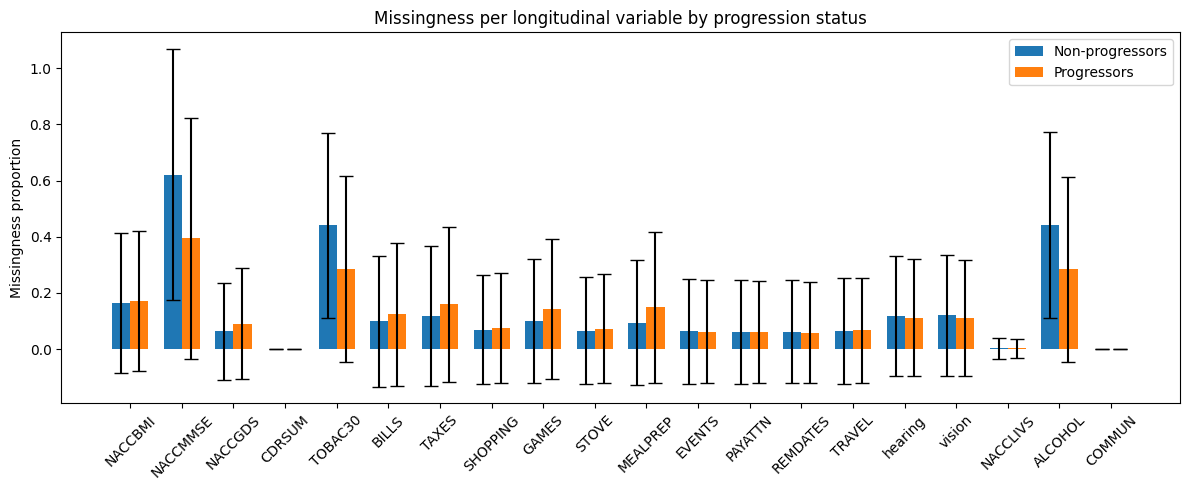

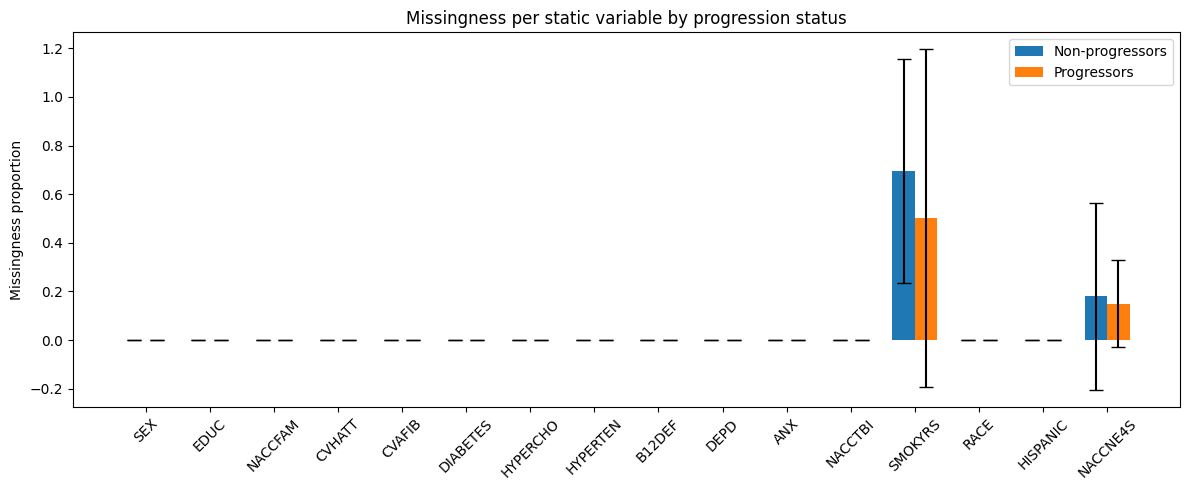

FROM missing_rates_CN.csv:


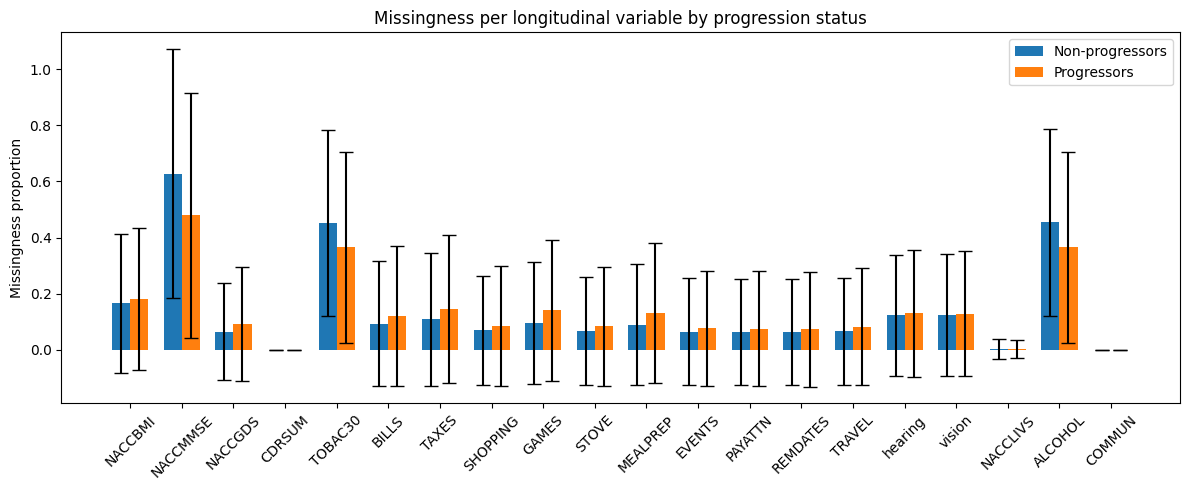

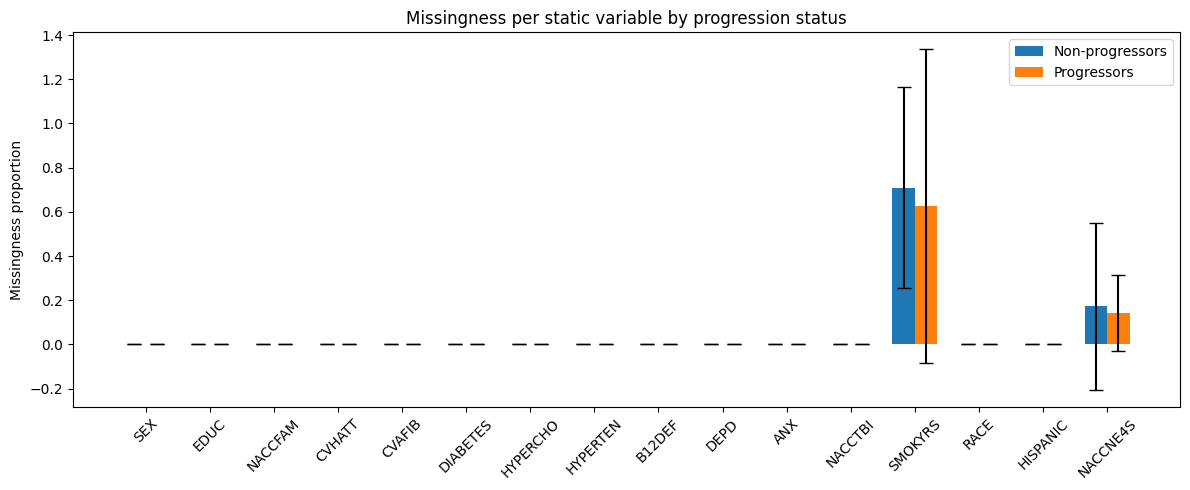

FROM missing_rates_MCI_AD.csv:


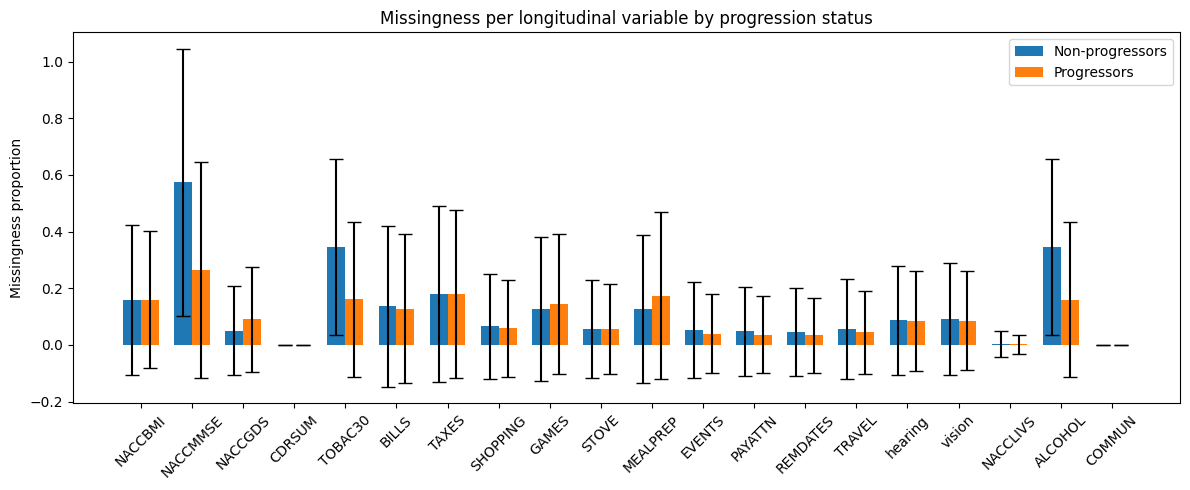

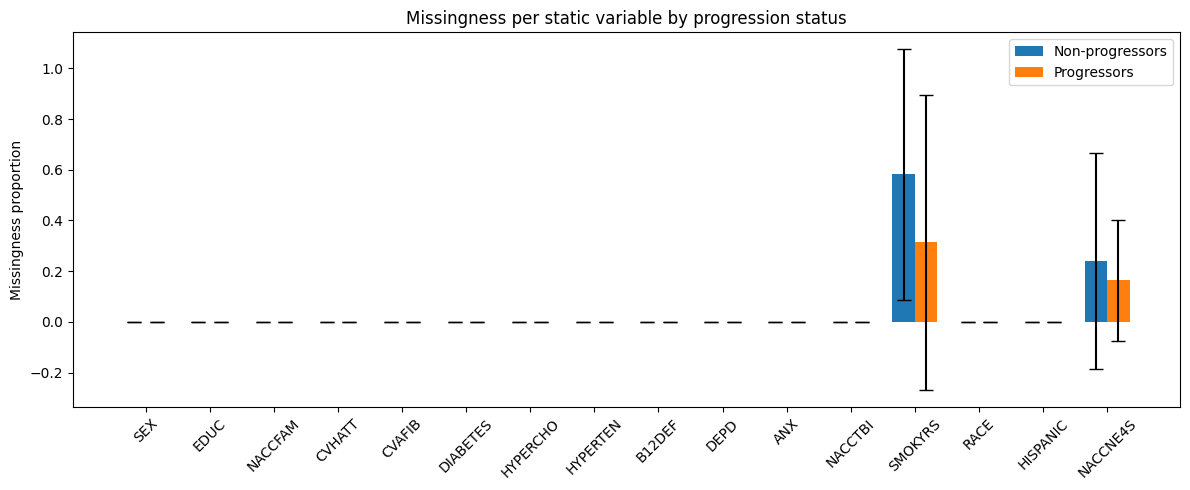

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

paths = ["missing_rates_combined.csv", "missing_rates_CN.csv", "missing_rates_MCI_AD.csv"]
for path in paths:
    print(f"FROM {path}:")
    csv = pd.read_csv(path)
    # Longitudinal columns stored as per-visit lists
    _LONG_COLS = [
        'NACCBMI', 'NACCMMSE', 'NACCGDS', 'CDRSUM', 'TOBAC30',
        'BILLS', 'TAXES', 'SHOPPING', 'GAMES', 'STOVE',
        'MEALPREP', 'EVENTS', 'PAYATTN', 'REMDATES', 'TRAVEL',
        'hearing', 'vision',
        'NACCLIVS', 'ALCOHOL','COMMUN'
    ]

    # Scalar columns — take the most-recent visit value
    _SCALAR_COLS = [
        'SEX', 'EDUC', 'NACCFAM',
        'CVHATT', 'CVAFIB', 'DIABETES', 'HYPERCHO', 'HYPERTEN',
        'B12DEF', 'DEPD', 'ANX', 'NACCTBI', 'SMOKYRS', 'RACE', 'HISPANIC',
        'NACCNE4S',
    ]

    long_var_count = len(_LONG_COLS)

    # error bar calculation using sd / sqr(sample size)
    # sample_size_np_sqr = csv.iloc[0,0] ** 0.5
    stdnp = csv.iloc[1, 1:long_var_count+1]
    # errnp = []
    # for x in stdnp:
    #     errnp.append(x/sample_size_np_sqr)

    # sample_size_p_sqr = csv.iloc[2,0] ** 0.5
    stdp = csv.iloc[3, 1:long_var_count+1]
    # errp = []
    # for x in stdp:
    #     errp.append(x/sample_size_p_sqr)

    x = np.arange(long_var_count)
    width = 0.35

    plt.figure(figsize=(12,5))

    plt.bar(x - width/2, csv.iloc[0, 1:long_var_count+1], width,
            yerr=stdnp, capsize=5, label='Non-progressors') ## used std for error bar

    plt.bar(x + width/2, csv.iloc[2, 1:long_var_count+1], width,
            yerr=stdp, capsize=5, label='Progressors') ## used std for error bar

    plt.xticks(x, _LONG_COLS, rotation=45)
    plt.ylabel("Missingness proportion")
    plt.title("Missingness per longitudinal variable by progression status")
    plt.legend()
    plt.tight_layout()
    plt.show()

    stat_var_count = len(_SCALAR_COLS)
    x = np.arange(stat_var_count)
    width = 0.35

    plt.figure(figsize=(12,5))

    plt.bar(x - width/2, csv.iloc[0, long_var_count+1:long_var_count+1+stat_var_count], width,
            yerr=csv.iloc[1, long_var_count+1:long_var_count+1+stat_var_count].tolist(),capsize=5, label='Non-progressors')

    plt.bar(x + width/2, csv.iloc[2, long_var_count+1:long_var_count+1+stat_var_count], width,
            yerr=csv.iloc[0, long_var_count+1:long_var_count+1+stat_var_count].tolist(),capsize=5, label='Progressors')

    plt.xticks(x, _SCALAR_COLS, rotation=45)
    plt.ylabel("Missingness proportion")
    plt.title("Missingness per static variable by progression status")
    plt.legend()
    plt.tight_layout()
    plt.show()


Missingness heatmap

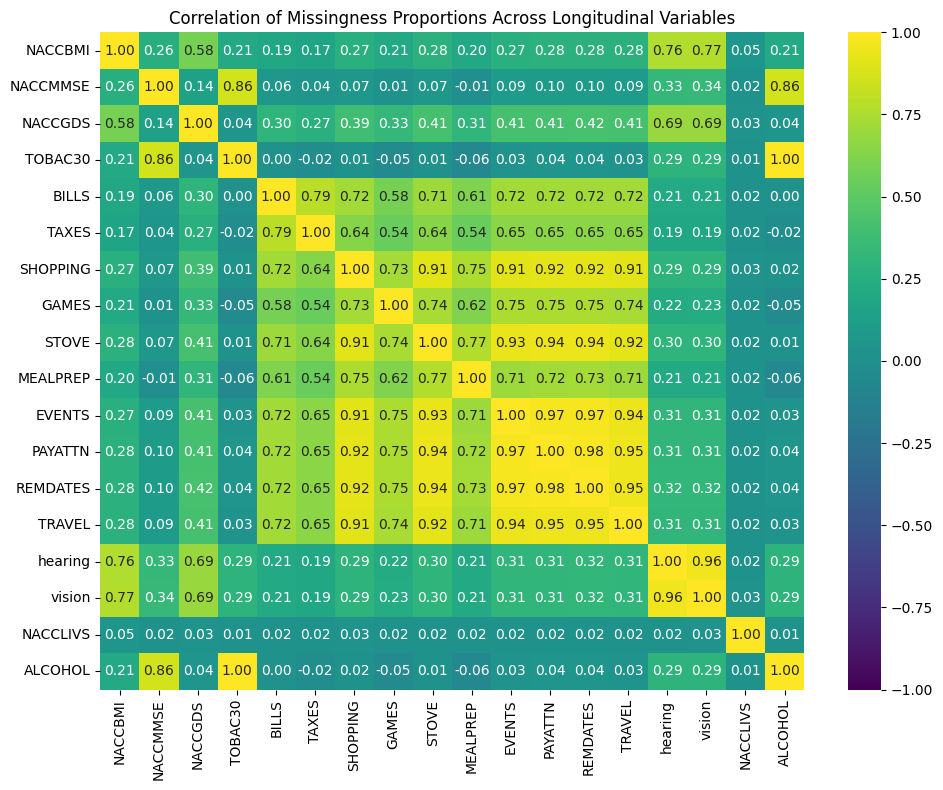

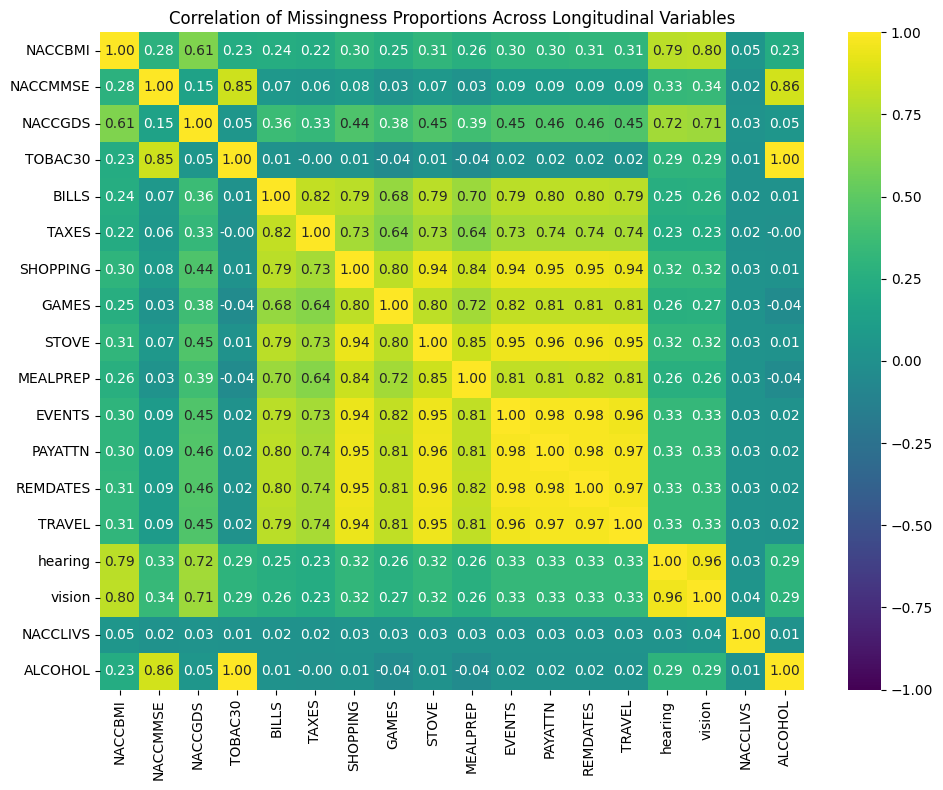

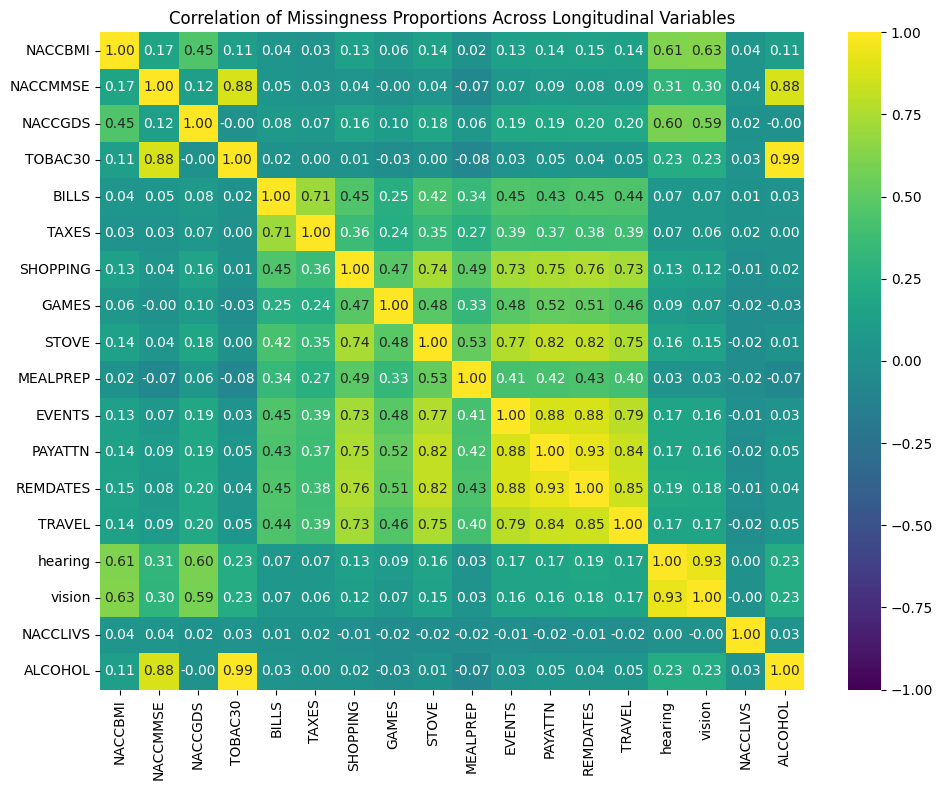

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def proportion_missing(x):
    """Return proportion missing inside a list, or NaN if not a list."""
    if isinstance(x, str): 
        x = eval(x)
    if isinstance(x, list):
        return np.mean(pd.isna(x))
    return np.nan

longitudinal_cols = [
    'NACCBMI', 'NACCMMSE', 'NACCGDS', 'CDRSUM', 'TOBAC30',
    'BILLS', 'TAXES', 'SHOPPING', 'GAMES', 'STOVE',
    'MEALPREP', 'EVENTS', 'PAYATTN', 'REMDATES', 'TRAVEL',
    'hearing', 'vision',
    'NACCLIVS', 'ALCOHOL', 'COMMUN'
]
nan = np.nan

lead_cn = pd.read_csv("datasets/Dataset_v2_1/lead_time_CN.csv")
lead_mci = pd.read_csv("datasets/Dataset_v2_1/lead_time_MCI_AD.csv")
pooled_cn = pd.read_csv("datasets/Dataset_v2_1/pooled_CN.csv")
pooled_mci = pd.read_csv("datasets/Dataset_v2_1/pooled_MCI_AD.csv")

grand = []
grand.append(pd.concat([lead_cn, lead_mci, pooled_cn, pooled_mci], ignore_index=True))
grand.append(pd.concat([lead_cn, pooled_cn], ignore_index=True))
grand.append(pd.concat([lead_mci, pooled_mci], ignore_index=True))

for i in range(3):
    df = grand[i]
    prop_df = pd.DataFrame({
        col: df[col].apply(proportion_missing)
        for col in longitudinal_cols
    })

    # Drop zero-variance columns — their correlations are undefined (NaN)
    prop_df = prop_df.loc[:, prop_df.std() > 0]

    corr = prop_df.corr().round(2)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", vmin=-1, vmax=1)
    plt.title("Correlation of Missingness Proportions Across Longitudinal Variables")
    plt.tight_layout()
    plt.show()

###
# First chart: combined
# Second: CN
# Third: MCI_AD
###


# NOTE CDRSUM is dropped from heatmap since it has no missingness, the correlation matrix returns nan for its variables. 

Missingness at each time point for longitudinal variables

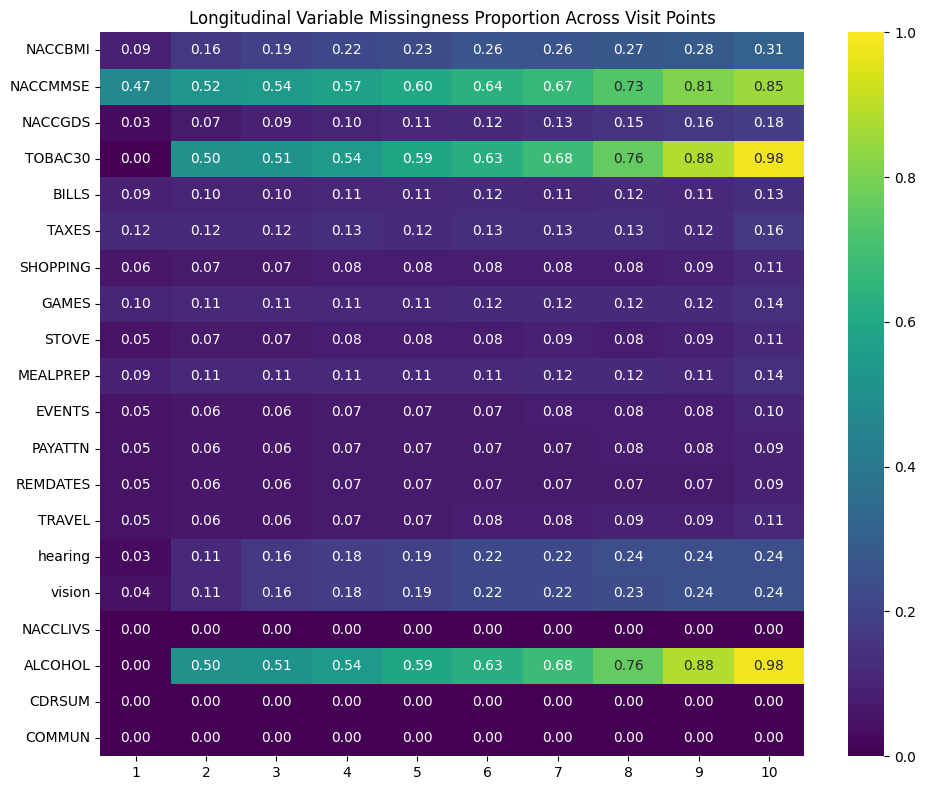

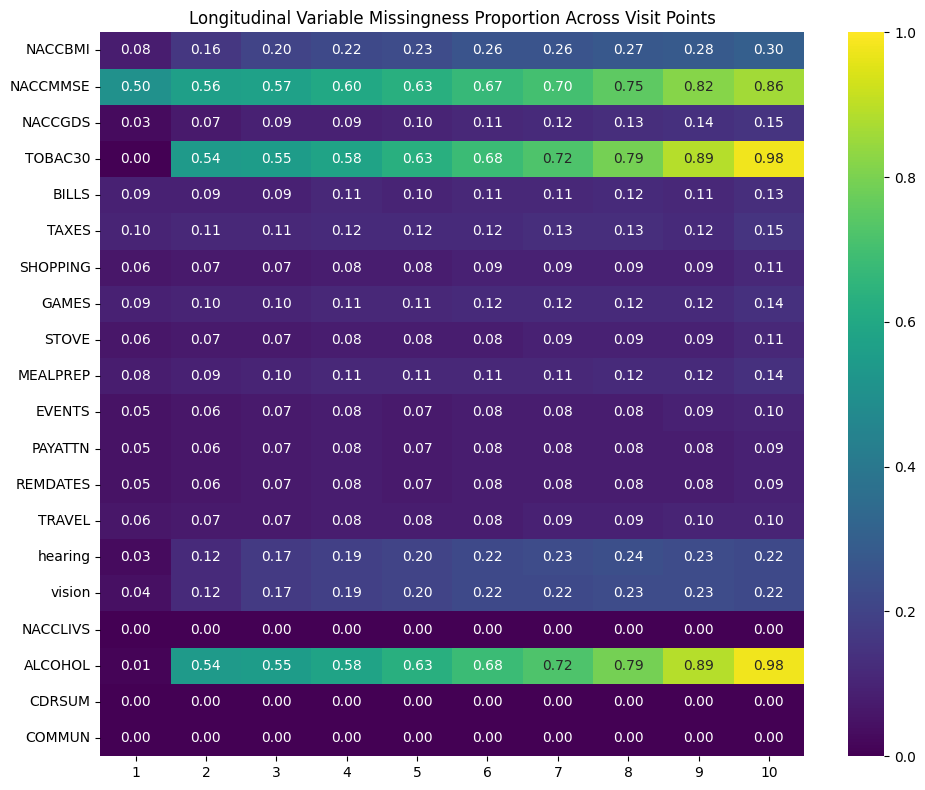

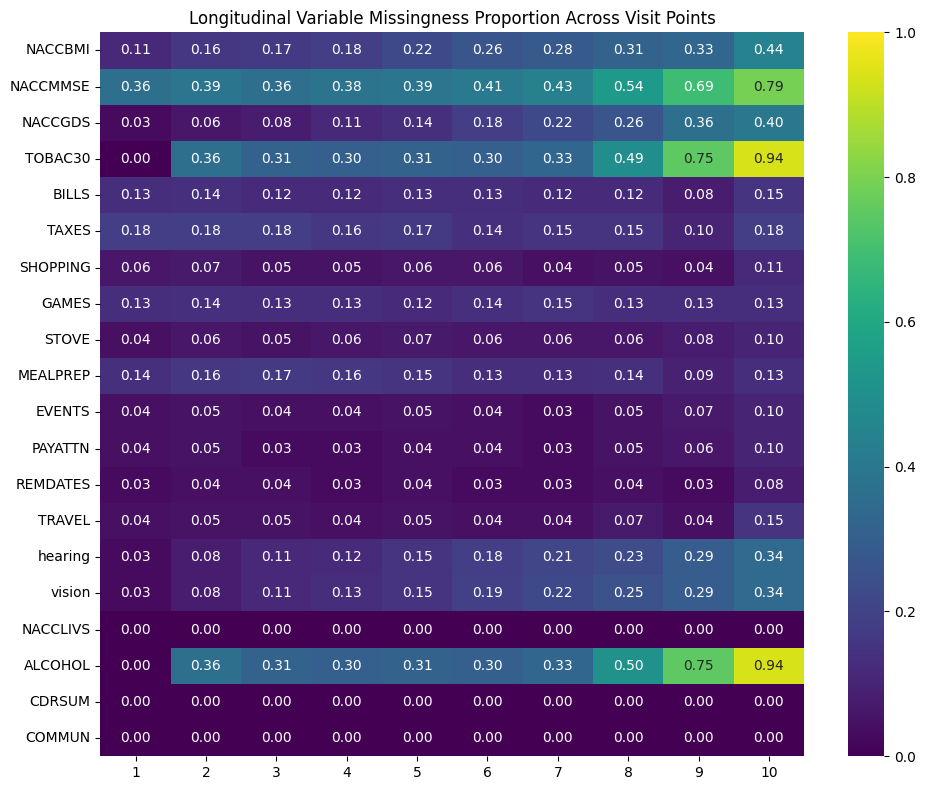

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Longitudinal columns stored as per-visit lists
longitudinal_cols = [
    'NACCBMI', 'NACCMMSE', 'NACCGDS',  'TOBAC30',
    'BILLS', 'TAXES', 'SHOPPING', 'GAMES', 'STOVE',
    'MEALPREP', 'EVENTS', 'PAYATTN', 'REMDATES', 'TRAVEL',
    'hearing', 'vision',
    'NACCLIVS', 'ALCOHOL','CDRSUM', 'COMMUN'
]
nan = np.nan

lead_cn = pd.read_csv("datasets/Dataset_v2_1/lead_time_CN.csv")
lead_mci = pd.read_csv("datasets/Dataset_v2_1/lead_time_MCI_AD.csv")
pooled_cn = pd.read_csv("datasets/Dataset_v2_1/pooled_CN.csv")
pooled_mci = pd.read_csv("datasets/Dataset_v2_1/pooled_MCI_AD.csv")

grand = []
grand.append(pd.concat([lead_cn, lead_mci, pooled_cn, pooled_mci], ignore_index=True))
grand.append(pd.concat([lead_cn, pooled_cn], ignore_index=True))
grand.append(pd.concat([lead_mci, pooled_mci], ignore_index=True))

for i in range(3):
    # missing counts
    m = pd.DataFrame(0, index=range(10), columns=longitudinal_cols)
    # total counts
    c = pd.DataFrame(0, index=range(10), columns=longitudinal_cols)
    # missing rates — float dtype to accept decimal values
    rates = pd.DataFrame(0.0, index=longitudinal_cols, columns=range(1, 11))

    def add_miss_count(row):
        v = int(row['n_visits'])
        for col in longitudinal_cols:
            l = []
            if isinstance(row[col], str):
                l = eval(row[col])
            for i in range(v):
                m.at[i, col] += int(np.isnan(l[i]))
                c.at[i, col] += 1

    for r in range(len(grand[i])):
        add_miss_count(grand[i].iloc[r])

    for a in range(10):
        for b in range(len(longitudinal_cols)):
            rates.iloc[b, a] = round(1.0 * m.iloc[a, b] / c.iloc[a, b], 2)

    plt.figure(figsize=(10, 8))
    sns.heatmap(rates, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
    plt.title("Longitudinal Variable Missingness Proportion Across Visit Points")
    plt.tight_layout()
    plt.show()
###
# First chart: combined
# Second: CN
# Third: MCI_AD
###
